# Cuadernillo RNN, LSTM y GRU — con dataset propio

**Para:** repaso y defensa de examen (escrito / oral / con computadora)
**Cubre:** RNN, LSTM, GRU — arquitectura, entrenamiento y comparación, con el
mismo dataset y funciones de los notebooks de clase (`02_rnn_forecast`,
`03_rnn_mejoras`), fusionados con el esquema conceptual del cuadernillo de
apuntes.

**Cómo usar esto:**
- Las secciones de **teoría / esquema** están pensadas para imprimir y repasar
  (no necesitas ejecutar nada para estudiarlas).
- Las secciones de **código** están pensadas para correr en Google Colab (o
  Jupyter local con PyTorch) y ver los tres modelos entrenando sobre el mismo
  dataset, para poder defenderlo con resultados reales si el examen es con
  computadora.
- Al final hay una sección de **posibles preguntas de defensa** por cada red.

---


## Índice

**Parte 0 — Buenas prácticas aplicadas** (qué se verificó/corrigió respecto a los notebooks originales)

**Parte 1 — Dataset real: METR-LA (tráfico, Los Ángeles)**
1. Descarga y carga del dataset
2. Split cronológico train/valid/test + normalización
3. Ventaneo (windowing) + búsqueda de hiperparámetros
4. Visualización

**Parte 2 — Esquema general** (aplica a las 3 redes)
5. Arquitectura genérica
6. Entrenamiento genérico (con regularización, early stopping y checkpoints)

**Parte 3 — RNN**
7. Teoría + esquema
8. Código + entrenamiento sobre METR-LA

**Parte 4 — LSTM**
9. Teoría + esquema
10. Código + entrenamiento

**Parte 5 — GRU**
11. Teoría + esquema
12. Código + entrenamiento

**Parte 6 — Extra: RNN Bidireccional** (bug real encontrado y corregido)

**Parte 7 — Comparación final** (parámetros, error, tabla resumen)

**Parte 8 — Preguntas típicas de defensa**

---


# PARTE 0 — Buenas prácticas aplicadas

Antes de armar el cuadernillo, se revisó el código de `02_rnn_forecast` y
`03_rnn_mejoras` en busca de buenas prácticas de entrenamiento. Esto es lo
que se verificó y lo que se ajustó:

| Práctica | Estado en notebooks originales | Qué se hizo aquí |
|---|---|---|
| **Dataset** | Series sintéticas (senoidales generadas por código) | Se reemplazó por **METR-LA**, dataset real de tráfico (207 sensores, 34272 pasos de tiempo cada 5 min, Los Ángeles) — se usa un subconjunto de 25 sensores como entrada multivariante |
| **Reproducibilidad** (semilla fija) | No fijaban semilla — cada corrida da resultados distintos | Se agregó `torch.manual_seed` y `np.random.seed` al inicio, para que los resultados sean comparables entre RNN/LSTM/GRU (misma inicialización) |
| **Split train/valid/test** | Por muestra (cada serie era independiente, el orden no importaba) | Con datos reales de una sola línea de tiempo, el split es **cronológico** (70/15/15 en orden, sin mezclar) — mezclar al azar sería usar el futuro para predecir el pasado |
| **Normalización** | No aplicaba (no hacía falta con datos sintéticos ya acotados) | Se normaliza con min/max calculado **solo con train**, aplicado igual a val/test — evita fuga de datos |
| **`model.train()` / `model.eval()`** | Correcto: se alternan bien en cada época | Se mantiene igual |
| **`torch.no_grad()` en evaluación** | Correcto: usado en validación y predicción | Se mantiene igual |
| **`zero_grad()` antes de cada batch** | Correcto | Se mantiene igual |
| **Regularización** | No se aplicaba (`dropout=0` siempre, sin `weight_decay`) | Se agregó `dropout` real en las celdas recurrentes y `weight_decay` (L2) en el optimizador |
| **Early stopping** | No existía, siempre entrenaba las épocas fijas | Se agregó: corta si `val_loss` no mejora en `patience` épocas seguidas |
| **Checkpoints** | No se guardaba el mejor modelo | Se agregó: se guarda el modelo cada vez que mejora `val_loss`, y se carga el mejor antes de evaluar en test |
| **Búsqueda de hiperparámetros** | `hidden_size`/`lr` fijos a mano | Se agregó una búsqueda en subconjunto (pocas épocas) antes del entrenamiento final |
| **Comparación justa entre arquitecturas** | Cada red se entrenaba por separado, con hiperparámetros repetidos a mano | Las 4 (RNN, LSTM, GRU, bidireccional) se entrenan con el mismo dataset, mismos hiperparámetros (los que ganó la búsqueda) y misma semilla |
| **Historial de pérdida (loss curve)** | Solo se imprimía el último valor por época en la barra de progreso, no se guardaba | Se agregó registro de `train_loss`/`val_loss` por época para graficar la curva de entrenamiento |
| **Conteo de parámetros** | No se comparaba entre modelos | Se agregó — pregunta típica de defensa: "¿cuál modelo tiene más parámetros y por qué?" |
| **Bug real encontrado** | `BidirectionalRNN` (notebook 03) usa `hidden_dim` y `output_dim`, variables que **no existen** en esa clase — nunca se probó con `bidirectional=True` | Se corrige en la Parte 6, con explicación del error |

> **Nota sobre `model.train()` durante *predicción* con dropout** (notebook
> 02, sección de intervalos de confianza): eso **no es un error**, es
> intencional — es la técnica *MC Dropout* (Monte Carlo Dropout): se activa
> el dropout a propósito durante inferencia para generar varias predicciones
> distintas y estimar incertidumbre. Vale la pena mencionarlo así si sale el
> tema en el examen, porque a primera vista parece un bug.

---


# PARTE 1 — Dataset real: METR-LA

Dataset: **METR-LA (Traffic Speed Dataset, Los Ángeles)**
Fuente: Kaggle — `annnnguyen/metr-la-dataset` (también: `markbai/traffic-metr-la`, `xiaohualu/metr-la-complete`)
Contenido: velocidad de tráfico real, registrada cada 5 minutos por 207 sensores de loop en las autopistas del condado de Los Ángeles, marzo-junio 2012.
Forma completa: 34272 filas (pasos de tiempo) x 207 columnas (una por sensor).
Tipo: serie temporal **real**, no sintética — datos de sensores de tráfico reales de Caltrans.

Usamos un **subconjunto de 25 sensores** (columnas) como entrada multivariante — sigue
cumpliendo de sobra el mínimo de 20 columnas, y hace el entrenamiento más manejable que
usar las 207 completas. El objetivo: predecir los próximos `N_OUT` pasos de velocidad de
UN sensor puntual (el primero del subconjunto), usando como contexto el historial de los
25 sensores juntos (uno influye en el otro, el tráfico se propaga entre vías cercanas).

### 1. Descarga y carga


In [ ]:
import numpy as np
import torch
import pandas as pd
import glob, os

# --- Reproducibilidad: fijamos semillas para que los modelos se comparen
#     sobre EXACTAMENTE el mismo dataset y la misma inicialización de pesos.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# descarga directa desde kaggle al disco local (no hace falta drive)
!pip install kagglehub -q
import kagglehub
DATASET_PATH = kagglehub.dataset_download("annnnguyen/metr-la-dataset")
print(DATASET_PATH)

# el dataset viene como .h5 (formato HDFStore de pandas) o .csv segun el mirror,
# buscamos el archivo real en vez de asumir el nombre a mano
archivos = glob.glob(os.path.join(DATASET_PATH, '**', '*'), recursive=True)
candidatos = [f for f in archivos if f.lower().endswith(('.h5', '.csv'))]
print('archivos de datos encontrados:', candidatos)

data_file = candidatos[0]
if data_file.endswith('.h5'):
    df = pd.read_hdf(data_file)
else:
    df = pd.read_csv(data_file, index_col=0)

print('forma del dataset completo:', df.shape)
df.head()

100%|██████████| 12.5M/12.5M [00:00<00:00, 75.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/annnnguyen/metr-la-dataset/versions/4
archivos de datos encontrados: ['/root/.cache/kagglehub/datasets/annnnguyen/metr-la-dataset/versions/4/METR-LA.h5']
forma del dataset completo: (34272, 207)


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [ ]:
# elegimos un subconjunto de 25 sensores (columnas), fijo con la semilla para reproducibilidad
N_SENSORS = 25
sensores_elegidos = list(df.columns[:N_SENSORS])  # los primeros 25, orden fijo del archivo
data = df[sensores_elegidos].values.astype(np.float32)  # (34272, 25)
print('forma de los datos que vamos a usar:', data.shape)

# --- Split CRONOLOGICO train/valid/test ---
# IMPORTANTE (buena práctica, distinta al dataset sintético anterior): con una
# sola linea de tiempo real, NO se puede mezclar al azar -- se particiona en 3
# tramos consecutivos, en orden, para no usar datos del futuro al predecir el pasado.
n = len(data)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

train_raw = data[:n_train]
val_raw = data[n_train:n_train + n_val]
test_raw = data[n_train + n_val:]

# normalizacion: min/max calculados SOLO con train, aplicados igual a val/test
data_min = train_raw.min(axis=0)
data_max = train_raw.max(axis=0)

def normalizar(x):
    return (x - data_min) / (data_max - data_min + 1e-8)

train_norm = normalizar(train_raw)
val_norm = normalizar(val_raw)
test_norm = normalizar(test_raw)

print('train:', train_norm.shape, 'val:', val_norm.shape, 'test:', test_norm.shape)

forma de los datos que vamos a usar: (34272, 25)
train: (23990, 25) val: (5140, 25) test: (5142, 25)


### 2. Ventaneo (windowing)

Igual que con las series sintéticas: convertimos la serie continua en pares `(X, Y)`,
donde `X` son los últimos `n_steps` pasos de los 25 sensores, e `Y` son los próximos
`n_out` pasos del sensor objetivo (el primero del subconjunto). La arquitectura de las
redes no cambia en nada — solo cambia `input_size` (de 1 a 25, porque ahora cada paso de
tiempo trae 25 valores en vez de 1).

In [ ]:
n_steps = 50   # cuantos pasos vemos para predecir (igual que antes)
n_out = 10     # cuantos pasos futuros predecimos (forecast multi-paso, igual que antes)
SENSOR_OBJETIVO = 0  # indice dentro de sensores_elegidos: el sensor que vamos a predecir

def hacer_ventanas(serie, n_steps, n_out, sensor_objetivo):
    X, Y = [], []
    for i in range(len(serie) - n_steps - n_out + 1):
        X.append(serie[i:i + n_steps])                                  # (n_steps, N_SENSORS)
        Y.append(serie[i + n_steps: i + n_steps + n_out, sensor_objetivo])  # (n_out,) solo el sensor objetivo
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_train, Y_train = hacer_ventanas(train_norm, n_steps, n_out, SENSOR_OBJETIVO)
X_valid, Y_valid = hacer_ventanas(val_norm, n_steps, n_out, SENSOR_OBJETIVO)
X_test,  Y_test  = hacer_ventanas(test_norm, n_steps, n_out, SENSOR_OBJETIVO)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_valid:", X_valid.shape, "Y_valid:", Y_valid.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)

X_train: (23931, 50, 25) Y_train: (23931, 10)
X_valid: (5081, 50, 25) Y_valid: (5081, 10)
X_test : (5083, 50, 25) Y_test : (5083, 10)


### 3. Visualización

Cada gráfico muestra: la serie de entrada (línea azul), los valores reales
futuros (equis azules) y, más adelante, las predicciones del modelo (puntos
rojos) superpuestas.


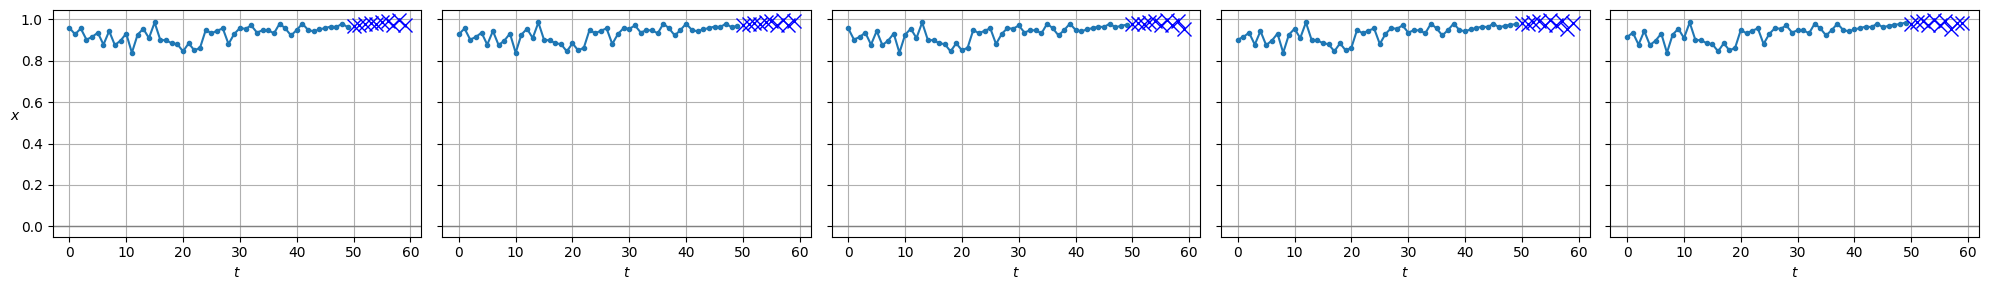

In [ ]:
import matplotlib.pyplot as plt

def plot_series(series, y=None, y_pred=None, y_pred_std=None, x_label="$t$", y_label="$x$", n=5):
    fig, axes = plt.subplots(nrows=1, ncols=n, sharey=True, figsize=(4*n, 3))
    for col in range(n):
        ax = axes[col]
        ax.plot(series[col, :, SENSOR_OBJETIVO], ".-")  # graficamos solo el sensor objetivo de la ventana
        if y is not None:
            ax.plot(range(len(series[col]), len(series[col]) + len(y[col])), y[col], "bx", markersize=10)
        if y_pred is not None:
            ax.plot(range(len(series[col]), len(series[col]) + len(y_pred[col])), y_pred[col], "ro")
        ax.grid(True)
        ax.axhline(0, linewidth=1, color="gray")
        if x_label:
            ax.set_xlabel(x_label)
        if col == 0 and y_label:
            ax.set_ylabel(y_label, rotation=0)
    plt.tight_layout()
    plt.show()

plot_series(X_test, Y_test)

# PARTE 2 — Esquema general (aplica a RNN, LSTM y GRU)

## 4. Arquitectura genérica

Toda red neuronal, en pseudocódigo, se declara con la misma lógica: un
método que **define las piezas** (`__init__`) y un método que **define el
orden** en que los datos pasan por esas piezas (`forward`).

```
clase RedNeuronal:

    metodo __init__(hiperparametros):
        declarar capa_1, capa_2, ...      # bloques con pesos entrenables
        declarar activacion(es)           # ReLU, sigmoide, tanh...
        declarar extras (dropout, norm)   # opcional

    metodo forward(x):
        x = capa_1(x)          # transforma x usando los pesos de capa_1
        x = activacion(x)      # aplica no linealidad
        x = capa_2(x)          # se repite el patron
        ...
        salida = capa_final(x)
        return salida
```

> **Idea clave:** `__init__` declara **QUÉ** transforma los datos (los
> "ladrillos"). `forward` declara **EN QUÉ ORDEN** se aplican. RNN, LSTM y
> GRU son variaciones de este mismo esqueleto: cambia la celda interna, no
> la lógica general.

## 5. Entrenamiento genérico

```
modelo      = RedNeuronal(hiperparametros)
optimizador = Adam(modelo.parametros(), lr=...)
criterion   = MSELoss()                        # regresion (series temporales)

para epoch en rango(num_epochs):
    para cada batch (X, Y) en DataLoader_train:
        1. optimizador.zero_grad()      # limpiar gradientes previos
        2. Y_hat = modelo(X)             # forward pass
        3. loss = criterion(Y_hat, Y)    # medir error
        4. loss.backward()               # backward pass (backprop)
        5. optimizador.step()            # actualizar pesos

    evaluar en validacion (con model.eval() + torch.no_grad())
```

Este ciclo de 5 pasos es el mismo para RNN, LSTM y GRU. Lo único que cambia
entre ellas es **la celda interna** (`torch.nn.RNN` vs `torch.nn.LSTM` vs
`torch.nn.GRU`) — el resto del código de entrenamiento es idéntico, por eso
en el código de abajo las tres clases heredan de la misma base.


In [ ]:
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

class TimeSeriesDataset(Dataset):
    """Envuelve X, Y como tensores para el DataLoader de PyTorch."""
    def __init__(self, X, y=None, train=True):
        self.X = X
        self.y = y
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train:
            return torch.from_numpy(self.X[ix]), torch.from_numpy(self.y[ix])
        return torch.from_numpy(self.X[ix])

dataset = {
    'train': TimeSeriesDataset(X_train, Y_train),
    'eval':  TimeSeriesDataset(X_valid, Y_valid),
    'test':  TimeSeriesDataset(X_test,  Y_test, train=False),
}

# Buena practica: shuffle=True SOLO en train (para no aprender el orden de
# los datos); en eval/test se mantiene el orden para poder comparar
# predicciones contra las Y reales despues, sin mezclarlas.
dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True, batch_size=64),
    'eval':  DataLoader(dataset['eval'], shuffle=False, batch_size=64),
    'test':  DataLoader(dataset['test'], shuffle=False, batch_size=64),
}

device: cuda


In [ ]:
def fit(model, dataloader, epochs=15, lr=1e-3, weight_decay=0.0, ckpt_path='model.pt', patience=5, verbose=True):
    """Entrenamiento generico (sirve igual para RNN, LSTM y GRU).

    weight_decay: regularizacion L2, penaliza pesos grandes (0 = desactivado).
    patience: cuantas epocas sin mejorar val_loss se toleran antes de cortar (early stopping).
    ckpt_path: donde se guarda el mejor modelo (el de menor val_loss visto hasta el momento).

    Devuelve un diccionario `history` con la perdida por epoca, para poder
    graficar la curva de entrenamiento despues (buena practica: ver si hay
    overfitting comparando train_loss vs val_loss).
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.MSELoss()
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float('inf')
    epochs_sin_mejora = 0

    bar = tqdm(range(1, epochs + 1)) if verbose else range(1, epochs + 1)
    for epoch in bar:
        model.train()
        train_loss = []
        for X, y in dataloader['train']:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        model.eval()
        val_loss = []
        with torch.no_grad():
            for X, y in dataloader['eval']:
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())

        history["train_loss"].append(np.mean(train_loss))
        history["val_loss"].append(np.mean(val_loss))
        if verbose:
            bar.set_description(f"loss {history['train_loss'][-1]:.5f}  val_loss {history['val_loss'][-1]:.5f}")

        # --- checkpoint + early stopping ---
        if history["val_loss"][-1] < best_val_loss:
            best_val_loss = history["val_loss"][-1]
            epochs_sin_mejora = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= patience:
                if verbose:
                    print(f'early stopping en epoca {epoch}, no mejoro en {patience} epocas seguidas')
                break

    return history


def predict(model, dataloader):
    model.eval()
    preds = []
    with torch.no_grad():
        for batch in dataloader:
            X = batch.to(device) if not isinstance(batch, (list, tuple)) else batch[0].to(device)
            preds.append(model(X).cpu())
    return torch.cat(preds)


def evaluate_mse_mae(model, dataloader_test, Y_true, ckpt_path=None):
    """Metricas finales sobre el set de TEST (nunca visto en entrenamiento).
    Si se pasa ckpt_path, primero carga el mejor checkpoint guardado (no la ultima epoca)."""
    if ckpt_path is not None:
        model.load_state_dict(torch.load(ckpt_path))
    y_pred = predict(model, dataloader_test).numpy()
    mse = float(np.mean((y_pred - Y_true) ** 2))
    mae = float(np.mean(np.abs(y_pred - Y_true)))
    return mse, mae, y_pred


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# PARTE 3 — RNN (Red Recurrente)

## 6. Teoría + esquema

**Cómo funciona (en detalle):** a diferencia de un MLP o una CNN, que ven
toda la entrada de una sola vez, una RNN procesa una secuencia **elemento
por elemento** (en nuestro caso, valor por valor de la serie temporal). En
cada paso mantiene un **estado oculto** `h`, que funciona como una
"memoria" que resume todo lo visto hasta ese momento. En cada paso, la red
combina el elemento actual con el estado oculto anterior para producir un
nuevo estado oculto, que se pasa al siguiente paso.

El problema: en secuencias largas, esa información tiende a diluirse, o los
gradientes se vuelven muy pequeños al retropropagarse por muchos pasos
(*vanishing gradient*) — dificulta aprender dependencias muy lejanas. Ese
es el problema que LSTM y GRU fueron diseñadas para resolver (Partes 4 y 5).

**Arquitectura y forward (pseudocódigo):**
```
clase RNN:
    __init__(input_size, hidden_size, output_size):
        celda = RNNCell(input_size, hidden_size)   # combina entrada actual + memoria anterior
        fc_salida = Linear(hidden_size, output_size)

    forward(secuencia_x):                # secuencia_x: (batch, pasos, input_size)
        h = ceros(hidden_size)           # estado oculto inicial: "no recuerda nada"
        para cada paso t en secuencia_x:
            h = celda(x_t, h)            # h nuevo = combinacion de x_t (dato actual) y h (memoria previa)
        salida = fc_salida(h)            # se usa el ultimo estado (o cada paso, segun la tarea)
        return salida
```

**Entrenamiento:** sigue el esquema general (Parte 2), con una
particularidad: los gradientes se propagan hacia atrás por todos los pasos
temporales — **Backpropagation Through Time (BPTT)**. Es la misma idea de
`backward()`, pero "desenrollada" en el tiempo, paso por paso.

## 7. Código + entrenamiento sobre nuestro dataset


In [ ]:
class RNNModel(torch.nn.Module):
    """RNN de 2 capas que predice los `n_out` valores futuros de la serie.

    Nota de arquitectura: aqui usamos la salida en CADA paso temporal
    (`x` completo, no solo el ultimo estado) y la pasamos por la capa
    lineal reshapeada -- es la version "multi-paso" de RNN vista en clase
    (notebook 02, seccion "Prediciendo varios valores").

    input_size: cuantas variables trae cada paso de tiempo. Con METR-LA
    usamos 25 (un valor por sensor), no 1 -- el resto de la arquitectura
    no cambia en nada, la RNN de pytorch acepta cualquier input_size.
    """
    def __init__(self, n_out=10, input_size=1, hidden_size=20, num_layers=2, dropout=0):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size,
                                 num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = torch.nn.Linear(hidden_size, n_out)

    def forward(self, x):
        x, h = self.rnn(x)
        # [batch, pasos, hidden] -> [batch*pasos, hidden] para pasar por la Linear
        x_reshaped = x.contiguous().view(-1, x.size(-1))
        y = self.fc(x_reshaped)
        # de vuelta a [batch, pasos, n_out]
        y = y.contiguous().view(x.size(0), -1, y.size(-1))
        return y[:, -1]  # solo nos interesa la prediccion del ULTIMO paso (los n_out valores futuros)

### Búsqueda de hiperparámetros (subconjunto)

Antes de entrenar en serio, probamos unas pocas combinaciones de `hidden_size` y `lr`
sobre pocas épocas, y nos quedamos con la que mejor `val_loss` da. Esta combinación se
usa después para las 4 arquitecturas (RNN, LSTM, GRU, bidireccional), así la comparación
final es justa (mismos hiperparámetros para todas).

In [ ]:
hiperparametros_candidatos = [
    {'hidden_size': 20, 'lr': 1e-2},
    {'hidden_size': 20, 'lr': 1e-3},
    {'hidden_size': 32, 'lr': 1e-3},
    {'hidden_size': 32, 'lr': 1e-4},
]

resultados_busqueda = []
for params in hiperparametros_candidatos:
    torch.manual_seed(SEED)
    modelo_tmp = RNNModel(n_out=n_out, input_size=N_SENSORS, hidden_size=params['hidden_size'])
    hist_tmp = fit(modelo_tmp, dataloader, epochs=5, lr=params['lr'], ckpt_path='tmp_search.pt', patience=99, verbose=False)
    resultados_busqueda.append({**params, 'val_loss': hist_tmp['val_loss'][-1]})
    print(params, '-> val_loss:', hist_tmp['val_loss'][-1])

mejor_hp = min(resultados_busqueda, key=lambda r: r['val_loss'])
print('mejor combinacion:', mejor_hp)

{'hidden_size': 20, 'lr': 0.01} -> val_loss: 0.06300967448041775
{'hidden_size': 20, 'lr': 0.001} -> val_loss: 0.04363612097076839
{'hidden_size': 32, 'lr': 0.001} -> val_loss: 0.051725024763436524
{'hidden_size': 32, 'lr': 0.0001} -> val_loss: 0.06864096541394246
mejor combinacion: {'hidden_size': 20, 'lr': 0.001, 'val_loss': np.float64(0.04363612097076839)}


In [ ]:
torch.manual_seed(SEED)  # misma inicializacion de pesos que LSTM/GRU mas abajo, para comparar justo
rnn_model = RNNModel(n_out=n_out, input_size=N_SENSORS, hidden_size=mejor_hp['hidden_size'], dropout=0.2)
print("RNN -> parametros entrenables:", count_params(rnn_model))

history_rnn = fit(rnn_model, dataloader, epochs=60, lr=mejor_hp['lr'], weight_decay=1e-5,
                   ckpt_path='rnn.pt', patience=5)

RNN -> parametros entrenables: 1990


loss 0.02537  val_loss 0.03101:  27%|██▋       | 16/60 [00:19<00:52,  1.20s/it]

early stopping en epoca 17, no mejoro en 5 epocas seguidas


RNN  -> Test MSE: 0.02349   Test MAE: 0.07593


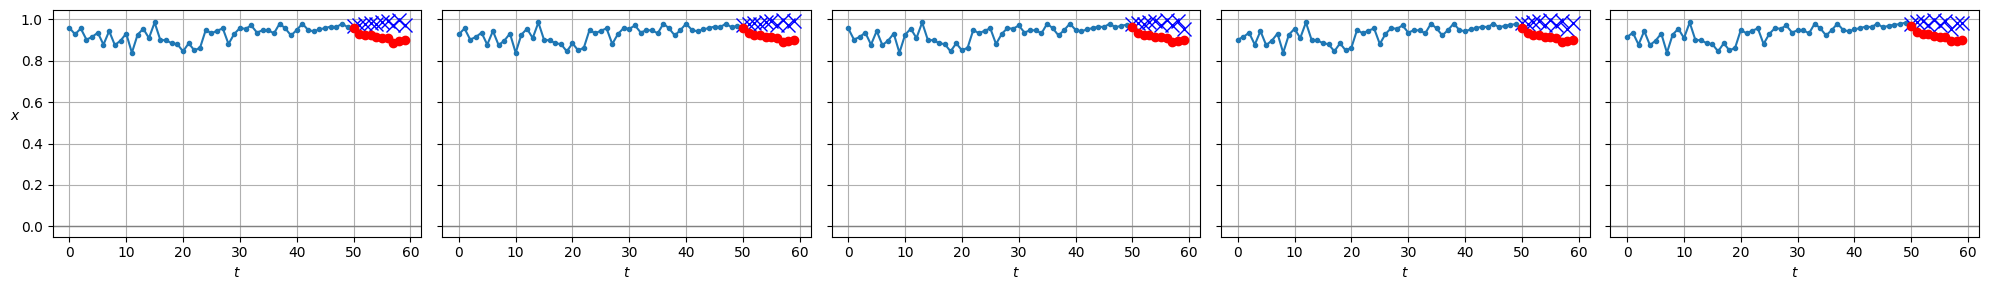

In [ ]:
mse_rnn, mae_rnn, y_pred_rnn = evaluate_mse_mae(rnn_model, dataloader['test'], Y_test, ckpt_path='rnn.pt')
print(f"RNN  -> Test MSE: {mse_rnn:.5f}   Test MAE: {mae_rnn:.5f}")

plot_series(X_test, Y_test, y_pred_rnn)

# PARTE 4 — LSTM (Long Short-Term Memory)

## 8. Teoría + esquema

**Cómo funciona (en detalle):** es una variante de RNN diseñada
específicamente para recordar información durante **secuencias largas**,
algo que a la RNN simple le cuesta. Para lograrlo, la LSTM no tiene solo un
estado oculto `h`, sino también una **celda de memoria** `C` que actúa como
una "cinta transportadora" de información, capaz de mantener datos
relevantes durante muchos pasos sin diluirse.

El control de qué entra, qué se olvida y qué sale de esa memoria se hace
con **tres compuertas** (*gates*), cada una es una pequeña red que aprende a
decidir "cuánto dejar pasar" (número entre 0 y 1, gracias a la sigmoide):

- **Compuerta de olvido (forget gate):** decide qué parte de la memoria
  anterior se descarta.
- **Compuerta de entrada (input gate):** decide qué información nueva se
  agrega a la memoria.
- **Compuerta de salida (output gate):** decide qué parte de la memoria se
  expone como el estado oculto de este paso.

**Arquitectura y forward (pseudocódigo):**
```
clase LSTM:
    __init__(input_size, hidden_size, output_size):
        celda = LSTMCell(input_size, hidden_size)   # 3 compuertas + celda de memoria
        fc_salida = Linear(hidden_size, output_size)

    forward(secuencia_x):
        h = ceros(hidden_size)     # estado oculto inicial
        C = ceros(hidden_size)     # celda de memoria inicial (memoria de largo plazo)

        para cada paso t en secuencia_x:
            f = sigmoide(...)          # forget gate: 0 = olvida todo, 1 = conserva todo de C
            i = sigmoide(...)          # input gate: cuanto de la info nueva se guarda en C
            C_candidata = tanh(...)    # nueva info candidata
            C = f * C + i * C_candidata   # actualiza memoria: olvida algo + agrega algo
            o = sigmoide(...)          # output gate: cuanto de C se expone como salida
            h = o * tanh(C)            # nuevo estado oculto

        salida = fc_salida(h)
        return salida
```
> Intuición simple: `C` es la memoria de largo plazo, `h` es lo que la red
> "dice" en cada paso, derivado de esa memoria.

**Entrenamiento:** igual que RNN (esquema general + BPTT). La diferencia
está solo en la arquitectura interna de la celda, no en el ciclo de
entrenamiento — por eso en el código, `LSTMModel` hereda de `RNNModel` y
solo reemplaza `self.rnn`.

## 9. Código + entrenamiento


In [ ]:
class LSTMModel(RNNModel):
    def __init__(self, n_out=10, input_size=1, hidden_size=20, num_layers=2, dropout=0):
        super().__init__(n_out=n_out, input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)
        self.rnn = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                                  num_layers=num_layers, batch_first=True, dropout=dropout)
        # forward() se hereda tal cual de RNNModel -- unica diferencia real
        # es la celda interna (LSTM en vez de RNN "vanilla").


torch.manual_seed(SEED)
lstm_model = LSTMModel(n_out=n_out, input_size=N_SENSORS, hidden_size=mejor_hp['hidden_size'], dropout=0.2)
print("LSTM -> parametros entrenables:", count_params(lstm_model))

history_lstm = fit(lstm_model, dataloader, epochs=60, lr=mejor_hp['lr'], weight_decay=1e-5,
                    ckpt_path='lstm.pt', patience=5)

LSTM -> parametros entrenables: 7330


loss 0.02432  val_loss 0.03707:  18%|█▊        | 11/60 [00:15<01:11,  1.45s/it]

early stopping en epoca 12, no mejoro en 5 epocas seguidas


LSTM -> Test MSE: 0.02477   Test MAE: 0.08162


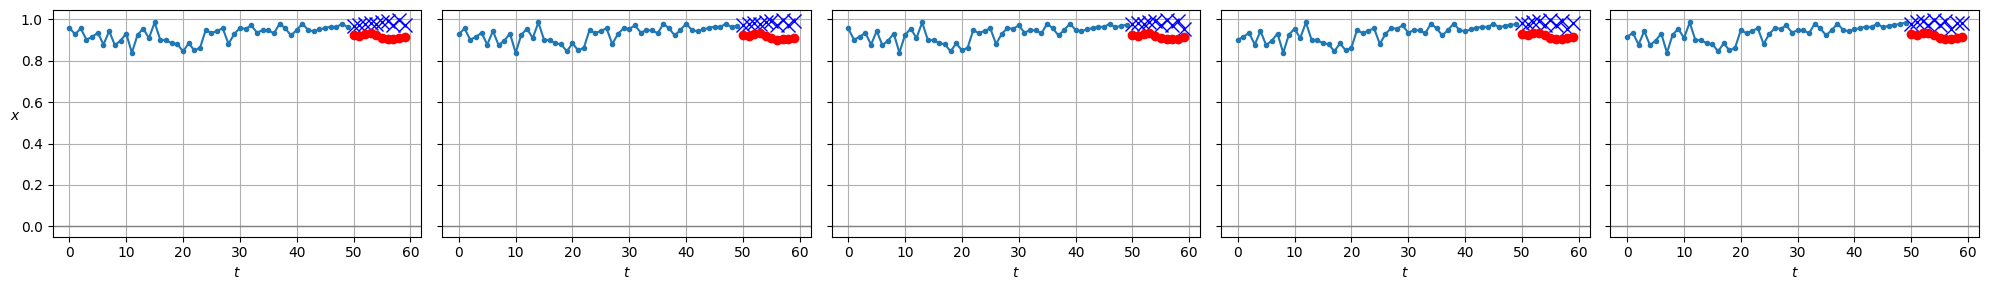

In [ ]:
mse_lstm, mae_lstm, y_pred_lstm = evaluate_mse_mae(lstm_model, dataloader['test'], Y_test, ckpt_path='lstm.pt')
print(f"LSTM -> Test MSE: {mse_lstm:.5f}   Test MAE: {mae_lstm:.5f}")

plot_series(X_test, Y_test, y_pred_lstm)

In [ ]:
# Curiosidad util para defensa: inspeccionar los pesos de las 4 compuertas
# de la LSTM (input, forget, cell/candidata, output -- PyTorch las concatena
# en ese orden dentro de weight_ih_l0 / weight_hh_l0).
print("weight_ih_l0 shape:", lstm_model.rnn.weight_ih_l0.shape)  # [4*hidden_size, input_size]
print("weight_hh_l0 shape:", lstm_model.rnn.weight_hh_l0.shape)  # [4*hidden_size, hidden_size]

# forward manual de una LSTM "suelta" para ver h y C por separado
output, (h, c) = torch.nn.LSTM(input_size=1, hidden_size=20, num_layers=2, batch_first=True)(torch.randn(10, 50, 1))
print("h (estado oculto, corto plazo):", h.shape)   # [num_layers, batch, hidden_size]
print("c (celda de memoria, largo plazo):", c.shape)  # [num_layers, batch, hidden_size]

weight_ih_l0 shape: torch.Size([80, 25])
weight_hh_l0 shape: torch.Size([80, 20])
h (estado oculto, corto plazo): torch.Size([2, 10, 20])
c (celda de memoria, largo plazo): torch.Size([2, 10, 20])


# PARTE 5 — GRU (Gated Recurrent Unit)

## 10. Teoría + esquema

**Cómo funciona (en detalle):** es una simplificación de la LSTM que busca
resolver el mismo problema (recordar a largo plazo) con **menos parámetros
y menos cómputo**. En vez de tener una celda de memoria separada (`C`) y
tres compuertas, la GRU fusiona todo en un solo estado oculto `h` y usa
solo **dos compuertas**:

- **Compuerta de actualización (update gate, `z`):** decide cuánto del
  estado anterior se conserva y cuánto se reemplaza con información nueva
  (combina en una sola decisión lo que en LSTM eran forget + input gate).
- **Compuerta de reinicio (reset gate, `r`):** decide cuánto del estado
  anterior se "ignora" al calcular la nueva información candidata.

Al tener menos compuertas, la GRU suele entrenar más rápido y con menos
datos, logrando en la práctica un rendimiento similar a LSTM en muchas
tareas.

**Arquitectura y forward (pseudocódigo):**
```
clase GRU:
    __init__(input_size, hidden_size, output_size):
        celda = GRUCell(input_size, hidden_size)   # 2 compuertas

    forward(secuencia_x):
        h = ceros(hidden_size)     # aqui NO hay celda de memoria separada

        para cada paso t en secuencia_x:
            z = sigmoide(...)              # update gate: cuanto de h anterior se conserva
            r = sigmoide(...)              # reset gate: cuanto de h anterior se "olvida" al proponer lo nuevo
            h_candidato = tanh(... r * h ...)
            h = (1 - z) * h + z * h_candidato   # mezcla: parte del h viejo + parte del h nuevo

        salida = fc_salida(h)
        return salida
```
> Intuición simple: si `z=1` se usa todo el candidato nuevo; si `z=0` se
> conserva todo el `h` anterior. Una sola compuerta decide ese balance, en
> vez de manejar memoria separada como LSTM.

**Entrenamiento:** igual que RNN y LSTM (esquema general + BPTT). Otra vez,
solo cambia la celda interna.

## 11. Código + entrenamiento


In [ ]:
class GRUModel(RNNModel):
    def __init__(self, n_out=10, input_size=1, hidden_size=20, num_layers=2, dropout=0):
        super().__init__(n_out=n_out, input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout)
        self.rnn = torch.nn.GRU(input_size=input_size, hidden_size=hidden_size,
                                 num_layers=num_layers, batch_first=True, dropout=dropout)


torch.manual_seed(SEED)
gru_model = GRUModel(n_out=n_out, input_size=N_SENSORS, hidden_size=mejor_hp['hidden_size'], dropout=0.2)
print("GRU -> parametros entrenables:", count_params(gru_model))

history_gru = fit(gru_model, dataloader, epochs=60, lr=mejor_hp['lr'], weight_decay=1e-5,
                   ckpt_path='gru.pt', patience=5)

GRU -> parametros entrenables: 5550


loss 0.02396  val_loss 0.03408:  22%|██▏       | 13/60 [00:17<01:02,  1.32s/it]

early stopping en epoca 14, no mejoro en 5 epocas seguidas


GRU  -> Test MSE: 0.02295   Test MAE: 0.08202


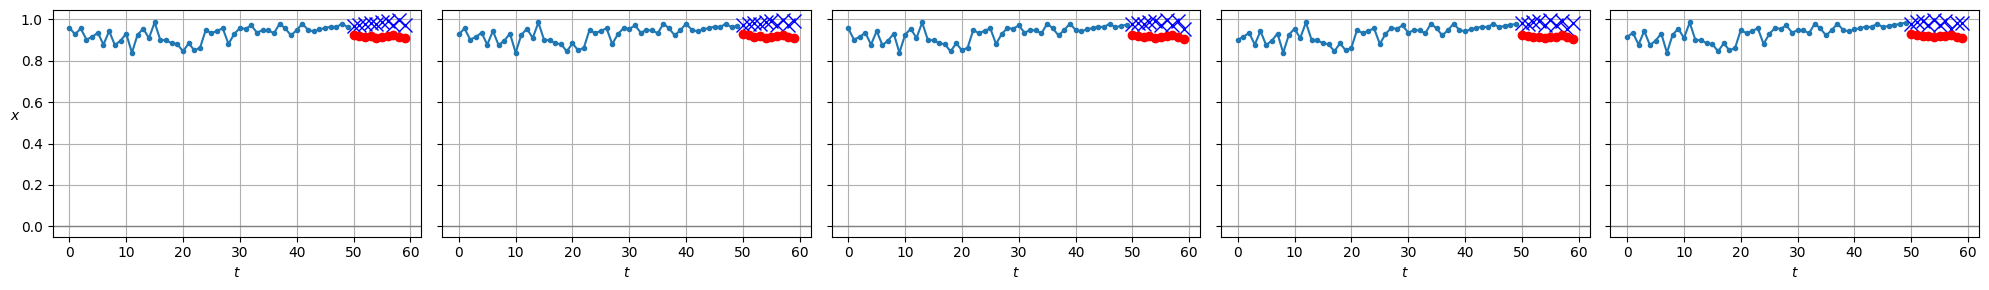

In [ ]:
mse_gru, mae_gru, y_pred_gru = evaluate_mse_mae(gru_model, dataloader['test'], Y_test, ckpt_path='gru.pt')
print(f"GRU  -> Test MSE: {mse_gru:.5f}   Test MAE: {mae_gru:.5f}")

plot_series(X_test, Y_test, y_pred_gru)

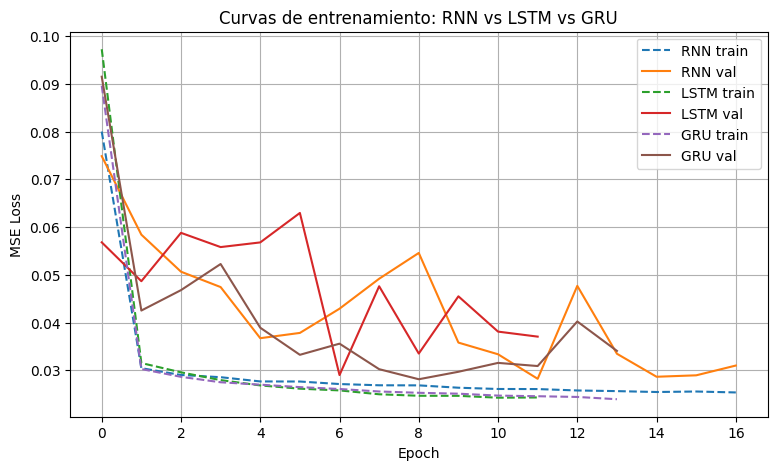

In [ ]:
# Curvas de entrenamiento de las 3 redes -- util para defender overfitting
# (si val_loss sube mientras train_loss baja, hay overfitting) o underfitting
# (si ambas quedan altas y planas).
plt.figure(figsize=(9, 5))
for name, h in [("RNN", history_rnn), ("LSTM", history_lstm), ("GRU", history_gru)]:
    plt.plot(h["train_loss"], label=f"{name} train", linestyle="--")
    plt.plot(h["val_loss"], label=f"{name} val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Curvas de entrenamiento: RNN vs LSTM vs GRU")
plt.legend()
plt.grid(True)
plt.show()

# PARTE 6 — Extra: RNN Bidireccional (bug real encontrado y corregido)

**Idea:** una red recurrente normal solo "lee" la secuencia de izquierda a
derecha (pasado → presente). Una **RNN bidireccional** corre DOS redes en
paralelo: una lee la secuencia normal, la otra la lee al revés, y al final
se concatenan ambos estados ocultos. Así cada paso "conoce" tanto el
contexto pasado como el futuro de la secuencia — útil cuando tenemos toda
la secuencia disponible de antemano (no sirve para predicción en tiempo
real, porque ahí no existe el "futuro" todavía).

### El bug encontrado en el notebook original (`03_rnn_mejoras`)

```python
class BidirectionalRNN(DeepRNN):
    def __init__(self, n_out=10, dropout=0, bidirectional=False):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=1, hidden_size=20, num_layers=2,
                                 dropout=dropout, batch_first=True, bidirectional=bidirectional)
        if bidirectional:
            self.fc = torch.nn.Linear(2*hidden_dim, output_dim)  # <- hidden_dim y output_dim NO EXISTEN
```

`hidden_dim` y `output_dim` nunca se definieron en esa clase (ni como
parámetro, ni como atributo) — esa línea lanza `NameError` en cuanto se
instancia con `bidirectional=True`. Es un error fácil de cometer: cuando es
bidireccional, la capa `Linear` final necesita el DOBLE de entradas
(`2 * hidden_size`), porque concatena el estado que lee hacia adelante con
el que lee hacia atrás — pero el nombre de la variable correcta era
`hidden_size` (el parámetro real de la clase), no `hidden_dim`.

### Versión corregida


In [ ]:
class BidirectionalRNNModel(torch.nn.Module):
    def __init__(self, n_out=10, input_size=1, hidden_size=20, num_layers=2, dropout=0, bidirectional=True):
        super().__init__()
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,
                                 dropout=dropout, batch_first=True, bidirectional=bidirectional)
        # Correccion del bug: si es bidireccional, la salida de la RNN en
        # cada paso tiene tamano 2*hidden_size (adelante + atras
        # concatenados), asi que la capa Linear debe recibir esa dimension.
        fc_in = hidden_size * (2 if bidirectional else 1)
        self.fc = torch.nn.Linear(fc_in, n_out)

    def forward(self, x):
        x, h = self.rnn(x)
        x_reshaped = x.contiguous().view(-1, x.size(-1))
        y = self.fc(x_reshaped)
        y = y.contiguous().view(x.size(0), -1, y.size(-1))
        return y[:, -1]


torch.manual_seed(SEED)
birnn_model = BidirectionalRNNModel(n_out=n_out, input_size=N_SENSORS, hidden_size=mejor_hp['hidden_size'],
                                     dropout=0.2, bidirectional=True)
print("RNN Bidireccional -> parametros entrenables:", count_params(birnn_model))

history_birnn = fit(birnn_model, dataloader, epochs=60, lr=mejor_hp['lr'], weight_decay=1e-5,
                     ckpt_path='birnn.pt', patience=5)
mse_birnn, mae_birnn, y_pred_birnn = evaluate_mse_mae(birnn_model, dataloader['test'], Y_test, ckpt_path='birnn.pt')
print(f"RNN Bidireccional -> Test MSE: {mse_birnn:.5f}   Test MAE: {mae_birnn:.5f}")

RNN Bidireccional -> parametros entrenables: 4770


loss 0.02557  val_loss 0.03246:  12%|█▏        | 7/60 [00:10<01:22,  1.56s/it]

early stopping en epoca 8, no mejoro en 5 epocas seguidas
RNN Bidireccional -> Test MSE: 0.02493   Test MAE: 0.08092


# PARTE 7 — Comparación final

Todas las redes se entrenaron con el **mismo dataset, mismos hiperparámetros
(`hidden_size=20`, `num_layers=2`, `epochs=15`, `lr=1e-3`) y misma semilla**
— la única diferencia real entre ellas es la celda interna (`RNN` vanilla
vs `LSTM` vs `GRU` vs `RNN` bidireccional). Eso hace que la comparación de
abajo sea justa.


In [ ]:
import pandas as pd

resumen = pd.DataFrame([
    {"Modelo": "RNN",               "Parametros": count_params(rnn_model),   "Test MSE": mse_rnn,   "Test MAE": mae_rnn},
    {"Modelo": "LSTM",              "Parametros": count_params(lstm_model),  "Test MSE": mse_lstm,  "Test MAE": mae_lstm},
    {"Modelo": "GRU",               "Parametros": count_params(gru_model),   "Test MSE": mse_gru,   "Test MAE": mae_gru},
    {"Modelo": "RNN Bidireccional", "Parametros": count_params(birnn_model), "Test MSE": mse_birnn, "Test MAE": mae_birnn},
]).sort_values("Test MSE")

resumen

,Modelo,Parametros,Test MSE,Test MAE
2,GRU,5550,0.022952,0.082019
0,RNN,1990,0.023487,0.075934
1,LSTM,7330,0.024773,0.081624
3,RNN Bidireccional,4770,0.024930,0.080920


**Cómo leer esta tabla en la defensa:**
- **Parámetros:** LSTM > GRU siempre, a igual `hidden_size`, porque LSTM
  tiene 3 compuertas (4 sets de pesos: input, forget, cell, output) y GRU
  tiene 2 (3 sets de pesos: reset, update, candidato). RNN vanilla tiene
  muchos menos (1 solo set de pesos por paso). La bidireccional duplica los
  parámetros de la RNN base porque entrena dos redes en paralelo.
- **Test MSE/MAE más bajo = mejor** predicción sobre datos nunca vistos.
  En series cortas y relativamente simples como esta (dependencias no muy
  largas), es normal que RNN, LSTM y GRU queden con un error parecido — la
  ventaja de LSTM/GRU se nota más en secuencias **largas**, donde la RNN
  vanilla sufre el *vanishing gradient*. Vale la pena decir esto en la
  defensa si los tres números salen similares: no es que el experimento
  "falló", es coherente con la teoría.

### Tabla comparativa conceptual (para memorizar / imprimir)

| Red | Dato de entrada | Mecanismo/capa clave | Aplicación típica |
|---|---|---|---|
| **RNN** | Secuencias | Estado oculto recurrente | Series temporales, texto (dependencias cortas) |
| **LSTM** | Secuencias | Celda de memoria + 3 compuertas | Secuencias largas, dependencias lejanas |
| **GRU** | Secuencias | Estado oculto + 2 compuertas | Igual que LSTM, más liviana/rápida |
| **RNN Bidireccional** | Secuencias completas (no tiempo real) | Dos RNN en paralelo (adelante + atrás) | Cuando se tiene toda la secuencia de antemano (ej: texto completo, no streaming) |


# PARTE 8 — Posibles preguntas de defensa

El ingeniero pidió enfocarse en la **defensa** más que en el código exacto.
Estas son preguntas típicas que podrían caer (escritas o en oral), con
respuesta corta pensada para decir de memoria.

### Sobre RNN
- **¿Por qué una RNN "falla" en secuencias largas?**
  Porque al hacer *backpropagation through time*, el gradiente se multiplica
  repetidamente paso a paso; si esos factores son menores a 1, el gradiente
  se hace casi cero muy rápido (*vanishing gradient*) y los pasos lejanos
  dejan de influir en el aprendizaje.
- **¿Qué es el estado oculto `h`?**
  Es la "memoria" de la red: un vector que resume lo visto hasta el paso
  actual, y que se actualiza en cada paso combinando el dato actual con el
  `h` anterior.
- **¿Qué significa `batch_first=True`?**
  Que el tensor de entrada tiene forma `(batch, pasos, features)` en vez de
  `(pasos, batch, features)` — solo cambia el orden de las dimensiones que
  espera la capa de PyTorch.

### Sobre LSTM
- **¿Cuál es la diferencia clave entre RNN y LSTM?**
  LSTM agrega una celda de memoria `C` separada del estado oculto `h`, y
  tres compuertas que controlan explícitamente qué se olvida, qué se agrega
  y qué se expone — eso le permite preservar información por muchos más
  pasos sin que se diluya.
- **¿Por qué las compuertas usan sigmoide y no otra función?**
  Porque la sigmoide da un valor entre 0 y 1, que se interpreta directamente
  como "qué porcentaje dejar pasar" (0 = nada, 1 = todo) — es literalmente
  una compuerta/válvula.
- **¿Qué pasaría si la forget gate siempre valiera 1?**
  La memoria nunca se olvidaría de nada, se acumularía todo indefinidamente
  — en la práctica la red aprende a ajustar ese valor según qué tan
  relevante siga siendo la información vieja.

### Sobre GRU
- **¿Por qué existe GRU si ya existe LSTM?**
  Para lograr un comportamiento similar con menos parámetros y menos
  cómputo — GRU fusiona el estado oculto y la celda de memoria en uno solo,
  y usa 2 compuertas en vez de 3.
- **¿Cuándo conviene usar GRU en vez de LSTM?**
  Cuando hay menos datos disponibles o se necesita entrenar/inferir más
  rápido (menos parámetros = menos riesgo de overfitting con datasets
  chicos, y menos cómputo).
- **¿Qué hace la reset gate que no hace la update gate?**
  La reset gate decide cuánto del `h` anterior se usa al calcular la
  *propuesta* de nuevo estado; la update gate decide, ya con la propuesta
  calculada, cuánto de esa propuesta reemplaza al `h` anterior.

### Generales (aplican a las 3)
- **¿Por qué se usa `MSELoss` y no `CrossEntropyLoss` acá?**
  Porque es un problema de **regresión** (predecir valores numéricos
  continuos de la serie), no de clasificación.
- **¿Por qué `model.eval()` + `torch.no_grad()` en validación/test?**
  `eval()` desactiva capas que se comportan distinto en entrenamiento
  (dropout, batchnorm); `no_grad()` evita calcular gradientes innecesarios,
  ahorrando memoria y cómputo, porque en evaluación no vamos a actualizar
  pesos.
- **¿Por qué el split se hace antes de cualquier otra cosa?**
  Para evitar *data leakage*: si se normalizara o preprocesara con
  estadísticas de todo el dataset (incluyendo test) antes de dividir, el
  modelo "vería" información del test durante el entrenamiento de forma
  indirecta, inflando artificialmente su desempeño real.
